In [ ]:
!pip install nltk textblob wordcloud

In [ ]:
import pandas as pd
import nltk
import re
import os
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from textblob import TextBlob

from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
   "nicapotato/womens-ecommerce-clothing-reviews"
)

# Load CSV
print("Dataset path:",path)
print(os.listdir(path))

Using Colab cache for faster access to the 'womens-ecommerce-clothing-reviews' dataset.
Dataset path: /kaggle/input/womens-ecommerce-clothing-reviews
['.nfs0000000089d6fb2a00000026', 'Womens Clothing E-Commerce Reviews.csv']


In [ ]:
import pandas as pd
import os

csv_file = os.path.join(path, "Womens Clothing E-Commerce Reviews.csv")

df = pd.read_csv(csv_file)


In [ ]:
df.head()

,Review Text
0,Absolutely wonderful - silky and sexy and comf...
1,Love this dress! it's sooo pretty. i happene...
2,I had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl..."
4,This shirt is very flattering to all due to th...


In [ ]:
stop_words = set(stopwords.words('english'))

def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['Clean_Text'] = df['Review Text'].apply(preprocess)

df.head()

,Review Text,Clean_Text
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky sexy comfortable
1,Love this dress! it's sooo pretty. i happene...,love dress sooo pretty happened find store im ...
2,I had such high hopes for this dress and reall...,high hopes dress really wanted work initially ...
3,"I love, love, love this jumpsuit. it's fun, fl...",love love love jumpsuit fun flirty fabulous ev...
4,This shirt is very flattering to all due to th...,shirt flattering due adjustable front tie perf...


In [ ]:
def get_sentiment(text):

    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

df['Sentiment'] = df['Clean_Text'].apply(get_sentiment)

df.head()

,Review Text,Clean_Text,Sentiment
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky sexy comfortable,Positive
1,Love this dress! it's sooo pretty. i happene...,love dress sooo pretty happened find store im ...,Positive
2,I had such high hopes for this dress and reall...,high hopes dress really wanted work initially ...,Positive
3,"I love, love, love this jumpsuit. it's fun, fl...",love love love jumpsuit fun flirty fabulous ev...,Positive
4,This shirt is very flattering to all due to th...,shirt flattering due adjustable front tie perf...,Positive


In [ ]:
print(df['Sentiment'].value_counts())

Sentiment
Positive    21135
Negative     1344
Neutral       162
Name: count, dtype: int64


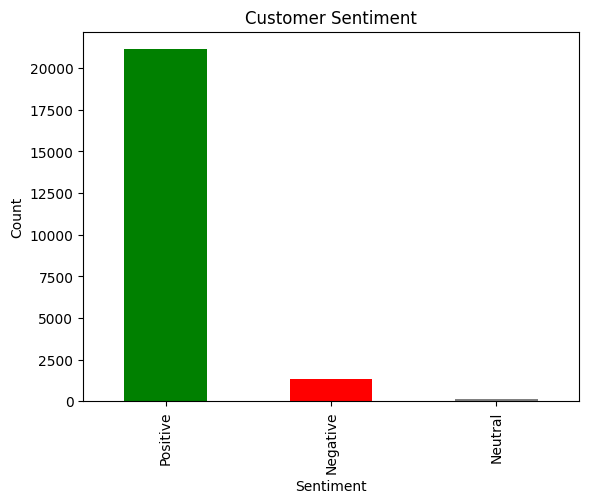

In [ ]:
df['Sentiment'].value_counts().plot(
    kind='bar',
    color=['green','red','gray']
)

plt.title("Customer Sentiment")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

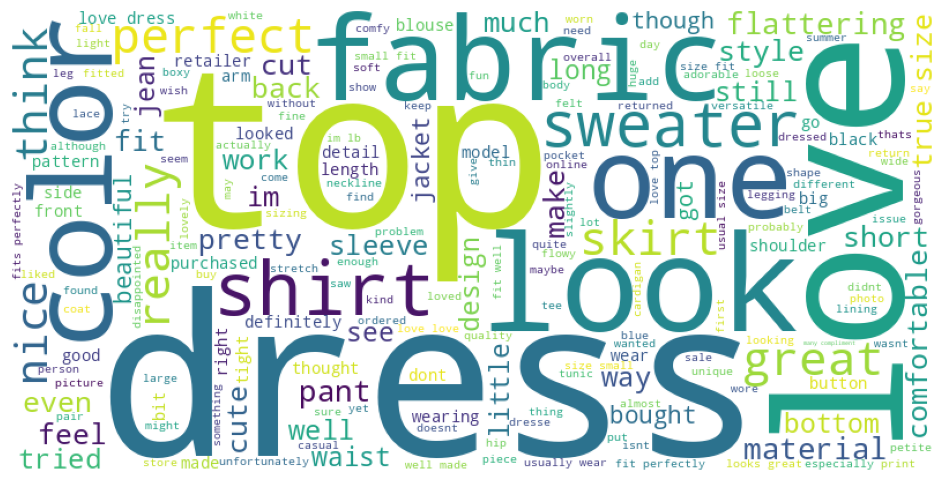

In [ ]:
text = " ".join(df['Clean_Text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [ ]:
negative = df[df['Sentiment']=="Negative"]

negative.head(10)

,Review Text,Clean_Text,Sentiment
8,I love this dress. i usually get an xs but it ...,love dress usually get xs runs little snug bus...,Negative
10,Dress runs small esp where the zipper area run...,dress runs small esp zipper area runs ordered ...,Negative
14,This is a nice choice for holiday gatherings. ...,nice choice holiday gatherings like length gra...,Negative
22,"First of all, this is not pullover styling. th...",first pullover styling side zipper wouldnt pur...,Negative
44,Tried this on today at my local retailer and h...,tried today local retailer comfortable flatter...,Negative
72,I have a short torso and this works well for m...,short torso works well c bought theres much st...,Negative
77,The zipper broke on this piece the first time ...,zipper broke piece first time wore disappointi...,Negative
84,I received this shirt in my typical xs and it ...,received shirt typical xs fits perfectly im cr...,Negative
85,"I was really hoping to like this, but it did n...",really hoping like look way model least sharkb...,Negative
105,I bought this lovely silk/velvet shirt in the ...,bought lovely silkvelvet shirt quotskyquot col...,Negative


In [ ]:
from collections import Counter

words = " ".join(negative['Clean_Text']).split()

common = Counter(words).most_common(20)

print(common)

[('dress', 571), ('like', 537), ('small', 504), ('size', 482), ('wear', 340), ('im', 321), ('little', 305), ('fabric', 293), ('would', 292), ('ordered', 271), ('back', 261), ('look', 227), ('one', 221), ('color', 208), ('really', 204), ('material', 192), ('shirt', 192), ('also', 190), ('thin', 190), ('even', 189)]


In [ ]:
print("Total Reviews:", len(df))

print()

print(df['Sentiment'].value_counts())

print()

print("Positive Review Percentage:")

print((df['Sentiment']=="Positive").mean()*100)

print()

print("Negative Review Percentage:")

print((df['Sentiment']=="Negative").mean()*100)

Total Reviews: 22641

Sentiment
Positive    21135
Negative     1344
Neutral       162
Name: count, dtype: int64

Positive Review Percentage:
93.34835033788261

Negative Review Percentage:
5.936133563005168
